In [17]:
import functools
import cv2
import numpy as np
from sklearn.cluster import DBSCAN
from PIL import Image
import tifffile as tiff
import matplotlib.pyplot as plt
from collections import Counter
import pandas as pd
from scipy.spatial.distance import cdist

In [34]:
buffer = 'NaHEPES'
concentration = 100
ph = 7
img_path = f'./images_peptide/{buffer}/{concentration} mM {buffer} pH {ph}.png' 
img_path = './images_peptide/others/Phage-3.png'
# img_path = './images_peptide/others/TAV2B.png'
img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)


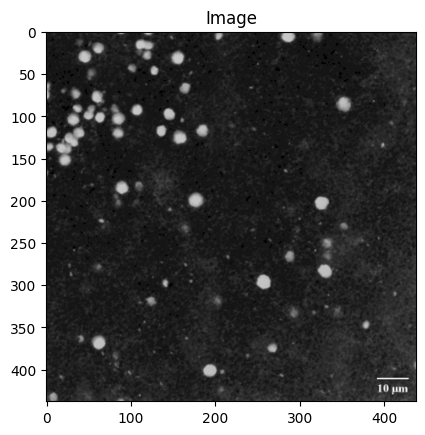

In [31]:
plt.imshow(img, cmap='gray')
plt.title('Image')
plt.show()  

In [28]:
def analyze_fft_anisotropy(img_path, buffer, concentration, ph):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    
    # 2D FFT
    fft = np.fft.fft2(img)
    fft_shift = np.fft.fftshift(fft)
    power_spectrum = np.abs(fft_shift) ** 2
    log_power = np.log1p(power_spectrum)

    h, w = power_spectrum.shape
    cy, cx = h // 2, w // 2

    # --- Polar transform of power spectrum ---
    y, x = np.indices(power_spectrum.shape)
    r = np.sqrt((x - cx)**2 + (y - cy)**2).astype(int)
    theta = np.arctan2(y - cy, x - cx)  # -pi to pi

    # --- Radial profile (frequency content) ---
    r_max = min(cx, cy)
    radial_profile = np.array([power_spectrum[r == i].mean() for i in range(r_max)])

    # --- Angular profile (directionality) ---
    n_angles = 180
    angle_bins = np.linspace(-np.pi, np.pi, n_angles + 1)
    angular_profile = np.zeros(n_angles)
    for i in range(n_angles):
        mask = (theta >= angle_bins[i]) & (theta < angle_bins[i+1]) & (r > 5) & (r < r_max)
        if mask.sum() > 0:
            angular_profile[i] = power_spectrum[mask].mean()

    # --- Anisotropy Index ---
    # Ranges 0 (isotropic) to 1 (fully anisotropic)
    ai = (angular_profile.max() - angular_profile.min()) / (angular_profile.max() + angular_profile.min())

    # --- Plot ---
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].imshow(img, cmap='gray')
    axes[0].set_title('Original')
    axes[1].imshow(log_power, cmap='inferno')
    axes[1].set_title('FFT Power Spectrum')
    axes[2].plot(np.linspace(-90, 90, n_angles), angular_profile)
    axes[2].set_title(f'Angular Profile\nAnisotropy Index = {ai:.3f}')
    axes[2].set_xlabel('Angle (degrees)')
    plt.suptitle(f'Buffer: {buffer}, Concentration: {concentration} mM, pH: {ph}')
    plt.tight_layout()
    plt.show()

    return ai, radial_profile, angular_profile


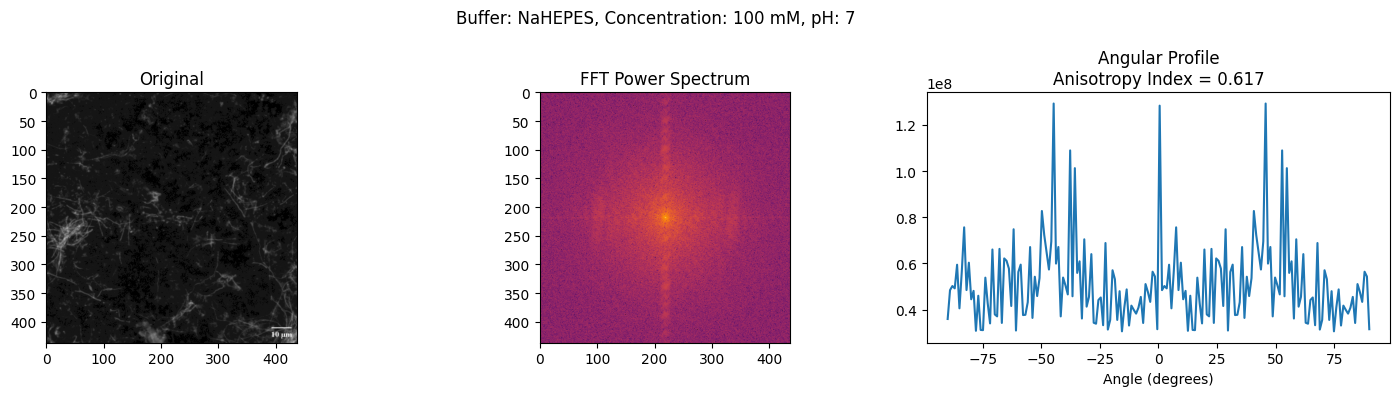

In [29]:
ai, radial_profile, angular_profile = analyze_fft_anisotropy(img_path, buffer, concentration, ph)


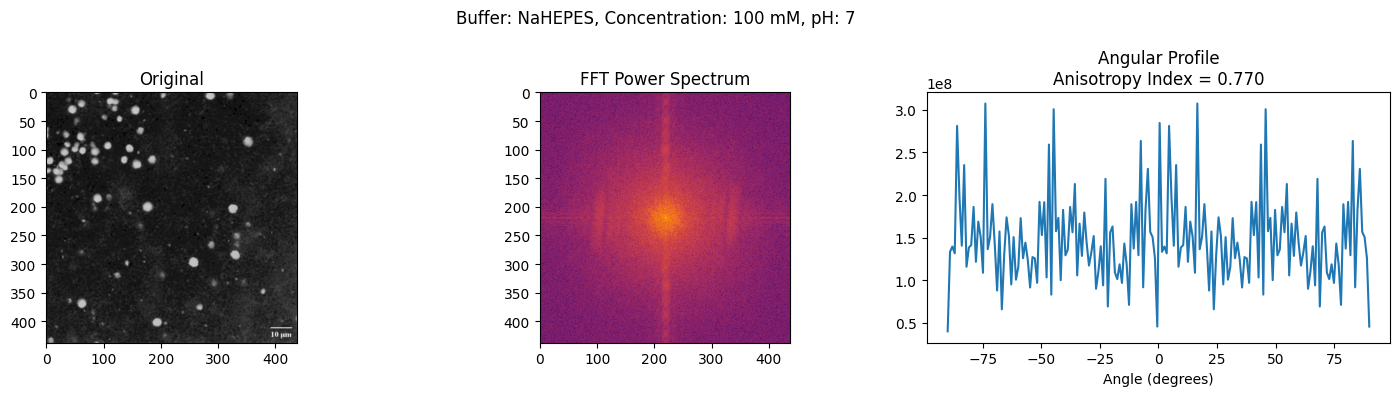

In [32]:
ai, radial_profile, angular_profile = analyze_fft_anisotropy(img_path, buffer, concentration, ph)

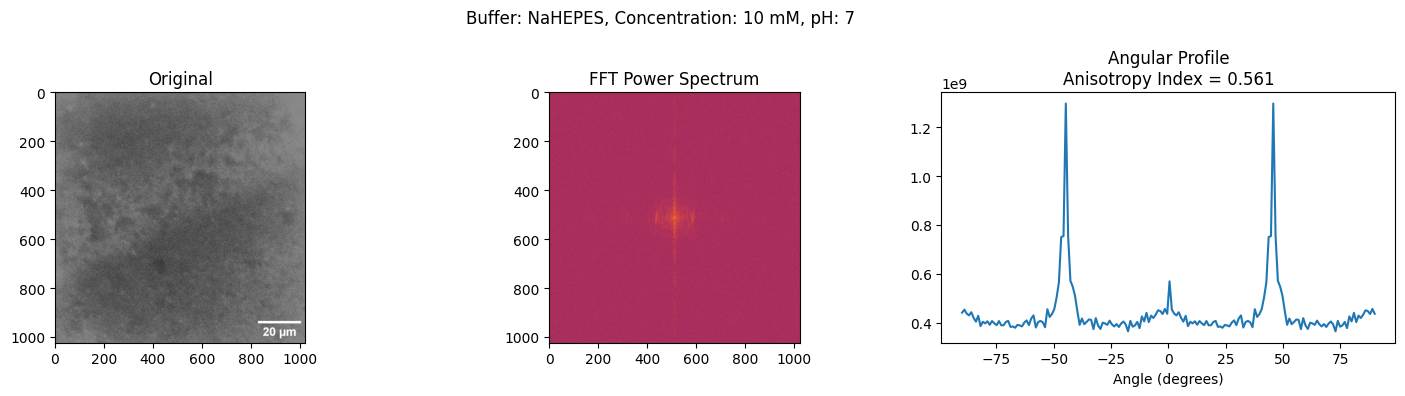

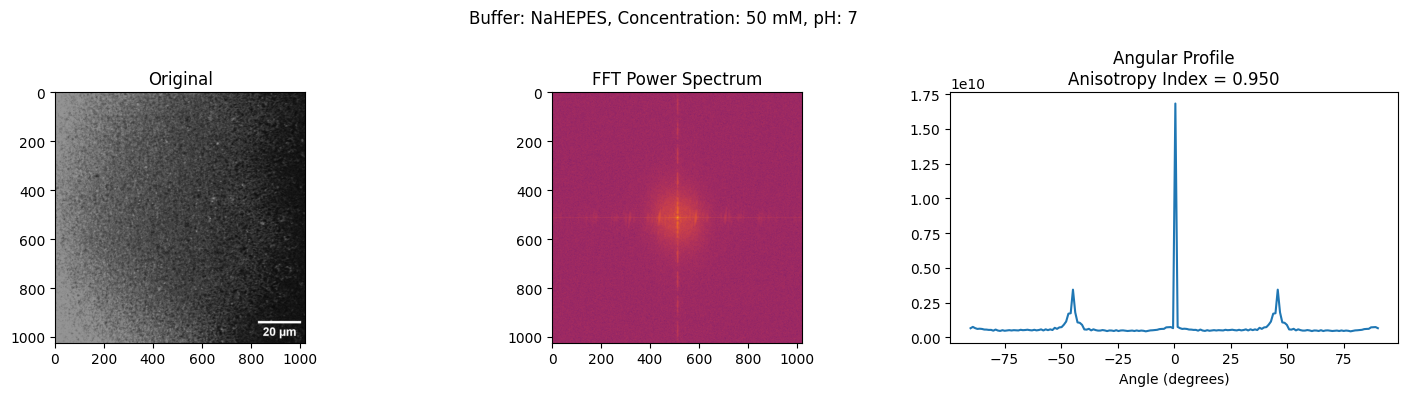

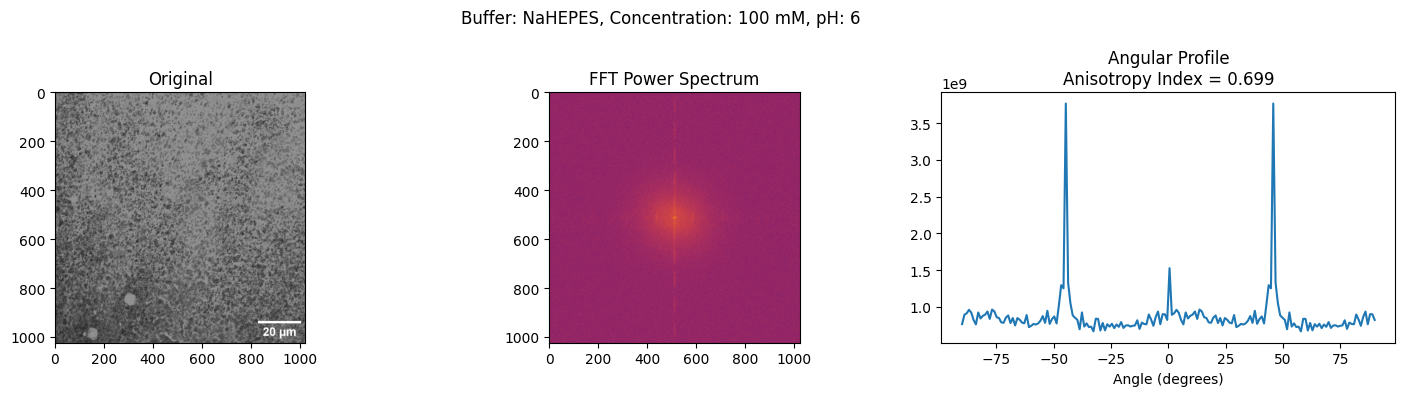

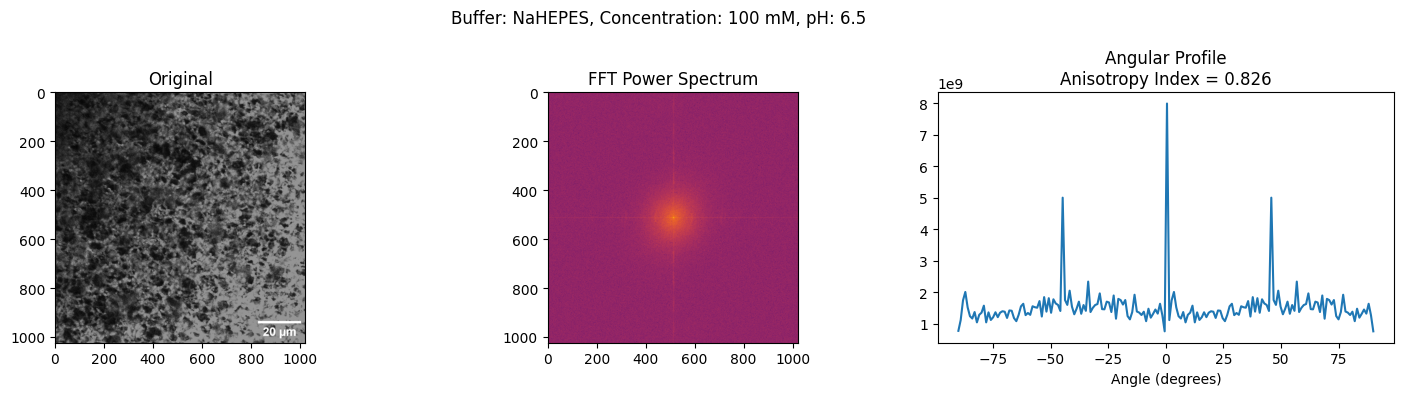

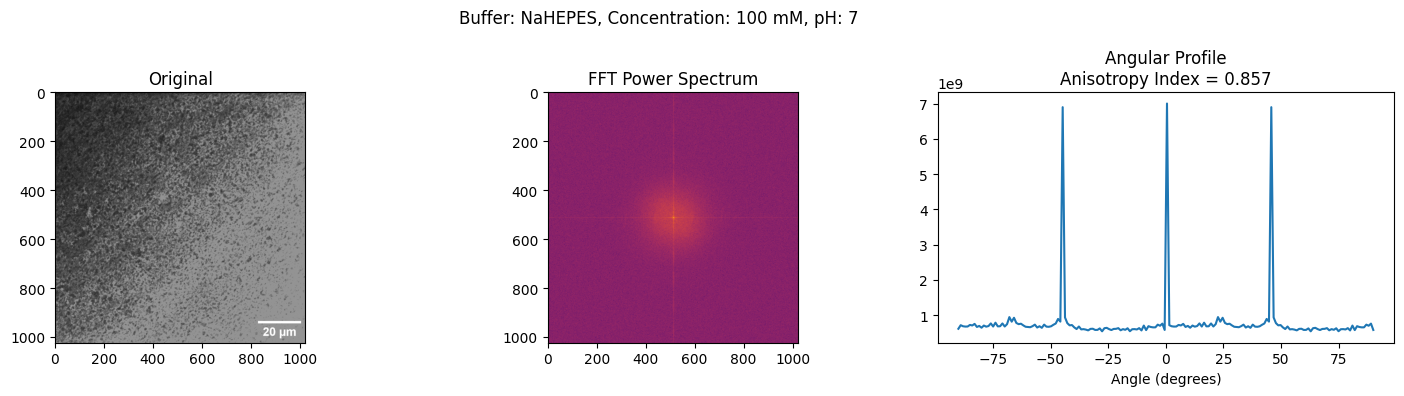

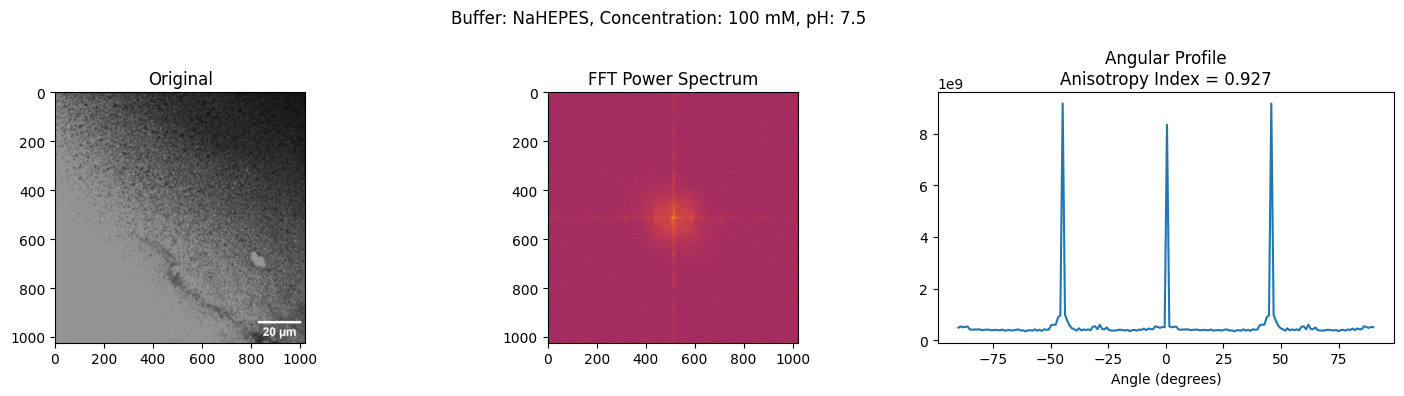

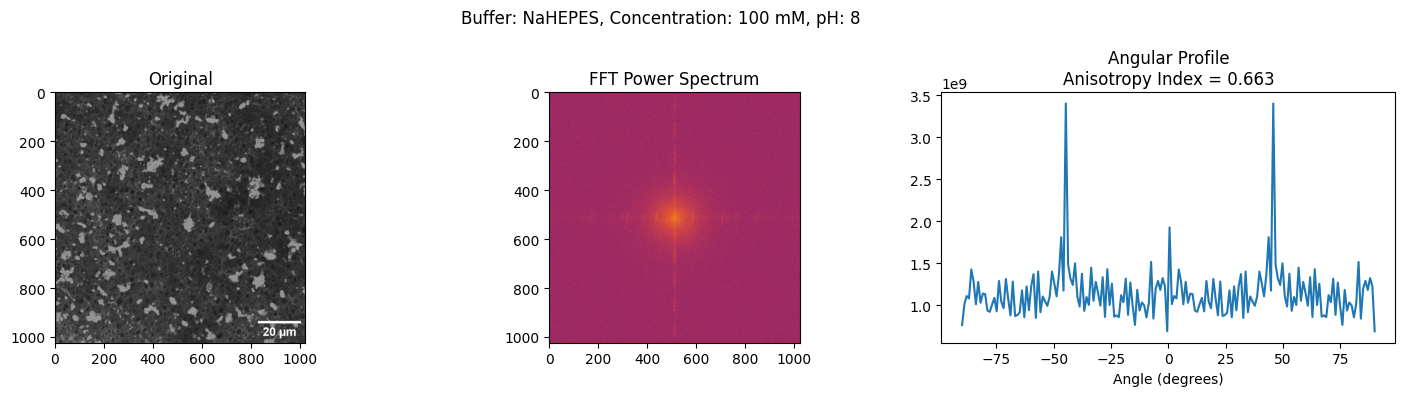

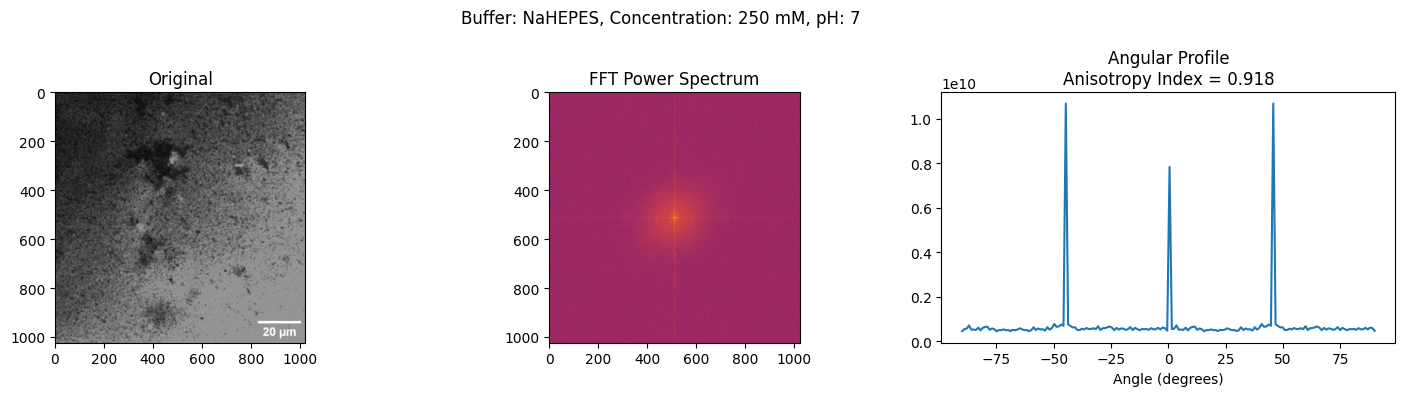

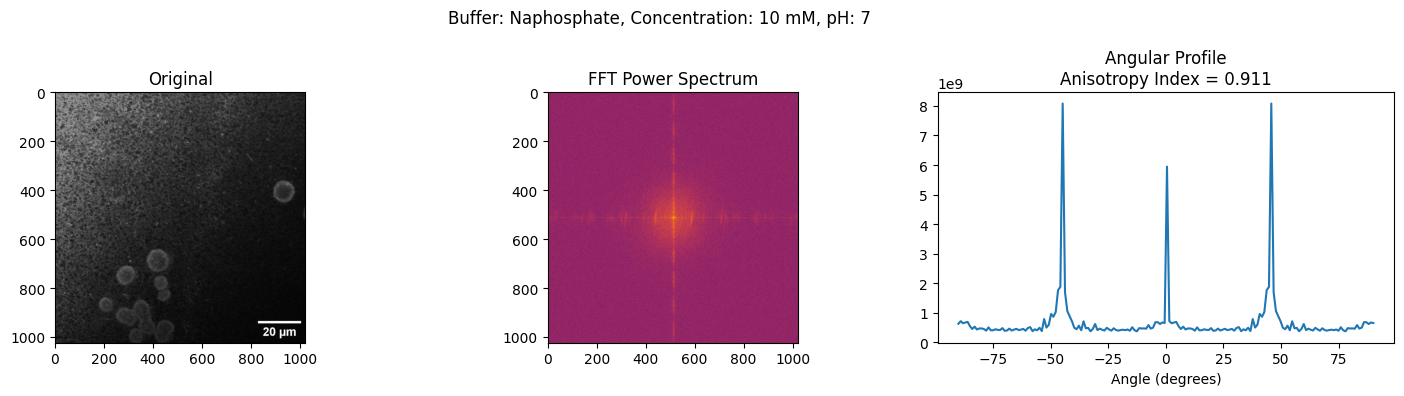

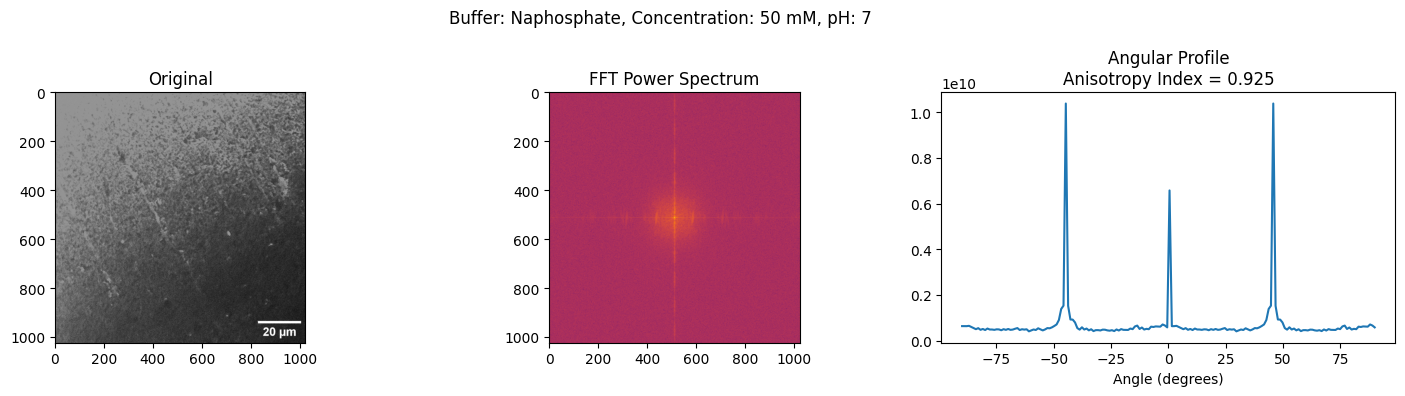

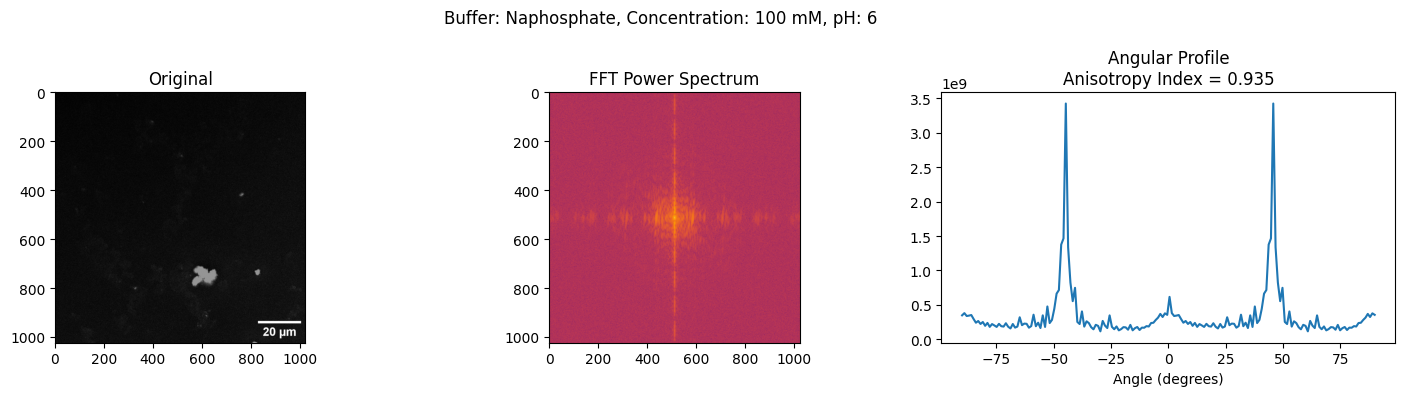

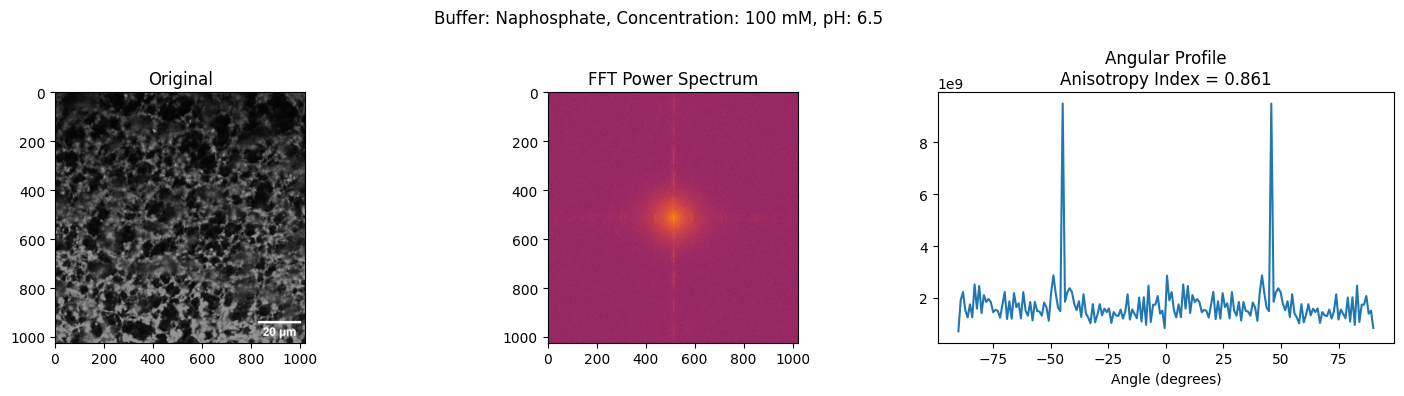

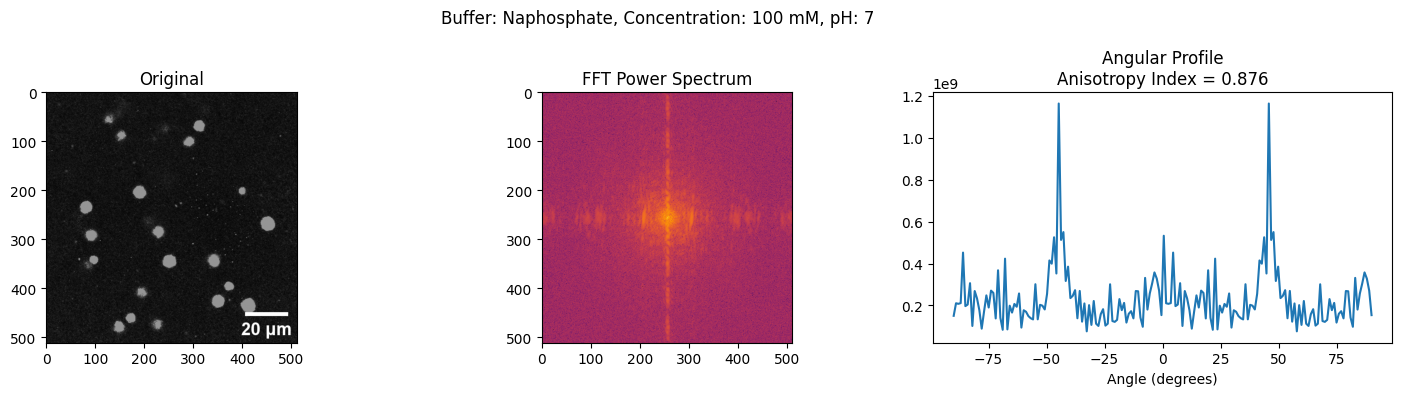

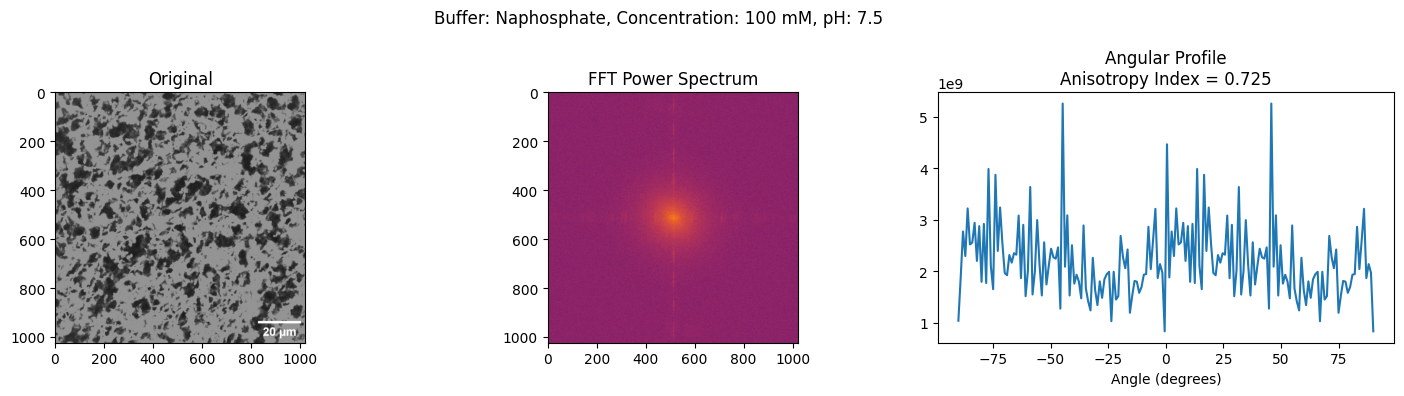

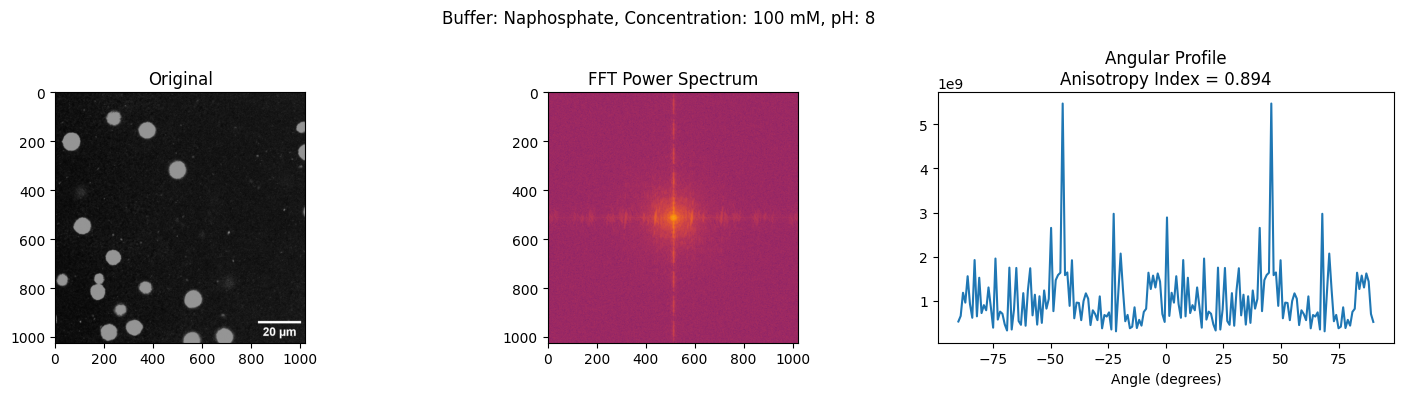

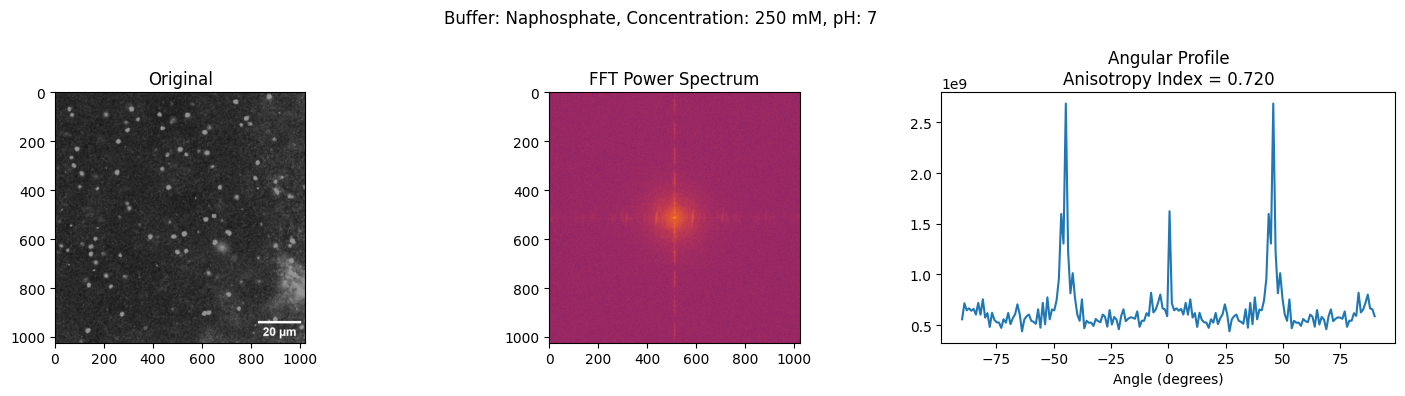

In [22]:
import os

buffers = ['NaHEPES', 'Naphosphate']
concentrations = [10, 50, 100, 250]   # 250 mM also exists in folder
ph_values = [6, 6.5, 7, 7.5, 8]

def load_all_images(base_path='./images_peptide'):
    """
    Returns a dict keyed by (buffer, concentration, ph) 
    and a DataFrame of what was found/missing.
    """
    images = {}
    records = []
    results = []

    for buffer in buffers:
        for conc in concentrations:
            for ph in ph_values:
                path = os.path.join(base_path, buffer, f'{conc} mM {buffer} pH {ph}.png')
                exists = os.path.exists(path)

                if exists:
                    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
                    loaded = img is not None
                    ai, radial_profile, angular_profile = analyze_fft_anisotropy(path, buffer, conc, ph)

                    results.append({
                        'buffer': buffer,
                        'concentration_mM': conc,
                        'pH': ph,
                        'anisotropy_index': ai
                    })

                    results_df = pd.DataFrame(results)
                else:
                    img = None
                    loaded = False

                images[(buffer, conc, ph)] = img
                records.append({
                    'buffer': buffer,
                    'concentration_mM': conc,
                    'pH': ph,
                    'path': path,
                    'exists': exists,
                    'loaded': loaded
                })

    df = pd.DataFrame(records)
    return images, df, results_df

images, df, results_df = load_all_images()

# Overview of what loaded
# print(df[['buffer', 'concentration_mM', 'pH', 'loaded']].to_string(index=False))
# print(f"\nTotal loaded: {df['loaded'].sum()} / {len(df)}")




In [24]:
results_df.sort_values(by=['anisotropy_index'], inplace=True)

In [25]:
results_df

,buffer,concentration_mM,pH,anisotropy_index
0,NaHEPES,10,7.0,0.560815
6,NaHEPES,100,8.0,0.663281
2,NaHEPES,100,6.0,0.699430
15,Naphosphate,250,7.0,0.719577
13,Naphosphate,100,7.5,0.724980
3,NaHEPES,100,6.5,0.826452
4,NaHEPES,100,7.0,0.857256
11,Naphosphate,100,6.5,0.860794
12,Naphosphate,100,7.0,0.875956
14,Naphosphate,100,8.0,0.894429
